In [1]:
#Si queremos que las imágenes sean mostradas en una ventana emergente quitar el inline
%matplotlib inline
#%matplotlib qt

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

In [2]:
# Cargamos la imagen a buscar
template = cv.imread('template/pattern.png')
template = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
template_edges = cv.Canny(template, threshold1=5, threshold2=200)

images = []
images_edges = []
for filename in os.listdir('images'):
    img = cv.imread(os.path.join('images', filename))
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_edges = cv.Canny(img, threshold1=5, threshold2=200)

    images.append(img)
    images_edges.append(img_edges)


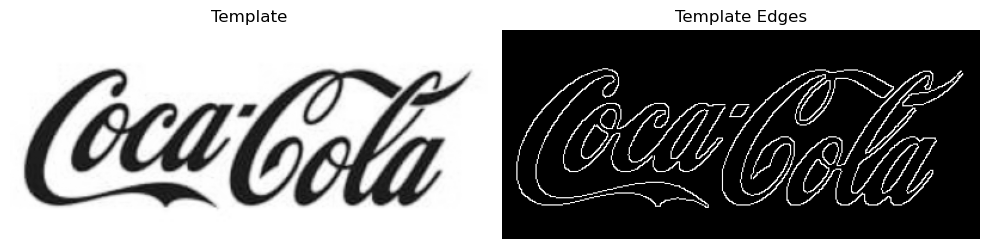

In [3]:
plt.figure(figsize=(10, 5))

# Plot the template
plt.subplot(1, 2, 1)
plt.imshow(template, cmap='gray')
plt.title('Template')
plt.axis('off')

# Plot the edges of the template
plt.subplot(1, 2, 2)
plt.imshow(template_edges, cmap='gray')
plt.title('Template Edges')
plt.axis('off')

plt.tight_layout()
plt.show()

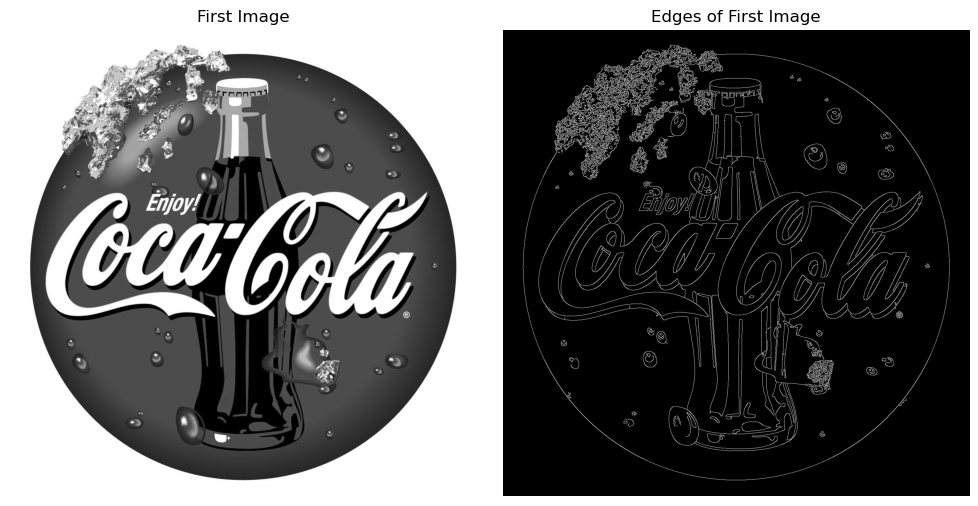

In [4]:
plt.figure(figsize=(10, 5))

# Plot the first image
plt.subplot(1, 2, 1)
plt.imshow(images[0], cmap='gray')
plt.title('First Image')
plt.axis('off')

# Plot the edges of the first image
plt.subplot(1, 2, 2)
plt.imshow(images_edges[0], cmap='gray')
plt.title('Edges of First Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
# Creamos el vector de características SIFT
sift = cv.SIFT_create(nfeatures=10000, contrastThreshold=0.0001, edgeThreshold=0.0001)

# Y buscamos según el algoritmo...
kp, des = sift.detectAndCompute(template_edges, None)

images_kp_des = {}

for i, img in enumerate(images_edges):
    kp_i, des_i = sift.detectAndCompute(img, None)
    images_kp_des[i] = (kp_i, des_i)

print(len(kp))
print(len(images_kp_des[0][0]))

234
3874


In [ ]:
# Inicializamos el detector ORB
orb = cv.ORB_create(nfeatures=3000, patchSize=2000)

kp, des = orb.detectAndCompute(template_edges, None)

images_kp_des = {}

for i, img in enumerate(images_edges):
    kp_i, des_i = orb.detectAndCompute(img, None)
    images_kp_des[i] = (kp_i, des_i)

print(len(kp))
print(len(images_kp_des[0][0]))

In [45]:
def flann_match(kp1, kp2, des1, des2, img1, img2):
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks = 2000000)
    flann = cv.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1,des2,k=2)

    good = []
    for m,n in matches:
        if m.distance < 0.75*n.distance:
            good.append(m)
    # print(len(good))


    MIN_MATCH_COUNT = 8

    if len(good) >= MIN_MATCH_COUNT:
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        matchesMask = mask.ravel().tolist()
        h,w = img1.shape
        pts = np.float32([ [0,0],[0,h],[w,h],[w,0] ]).reshape(-1,1,2)
        dst = cv.perspectiveTransform(pts, M)
        img3 = cv.polylines(img2, [np.int32(dst)], True, 255, 3, cv.LINE_AA)
        # print(mask)
        return good, matchesMask, img3
    else:
        print( "No se encontraron suficientes coincidencias - {}/{}".format(len(good), MIN_MATCH_COUNT) )
        matchesMask = None

In [ ]:
def brute_force_match(kp1, kp2, des1, des2, img1, img2):
    bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)

    # Coincidimos descriptores.
    matches = bf.match(des1, des2)

    # Los ordenamos según distancia
    matches = sorted(matches, key = lambda x:x.distance)

    img3 = cv.drawMatches(img1,kp1,img2,kp2,matches[:30],None,flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.imshow(img3),plt.show()

In [46]:
matches = {}
for i, (kp_i, des_i) in images_kp_des.items():
    try:
        good, mask, img_matches = flann_match(kp, kp_i, des, des_i, template, images_edges[i])
        matches[i] = (good, mask, img_matches)
    except Exception as e:
        print(f"Error processing image {i}: {e}")

No se encontraron suficientes coincidencias - 4/8
Error processing image 0: cannot unpack non-iterable NoneType object
No se encontraron suficientes coincidencias - 1/8
Error processing image 1: cannot unpack non-iterable NoneType object


In [ ]:
matches = {}
for i, (kp_i, des_i) in images_kp_des.items():
    try:
        img_matches = brute_force_match(kp, kp_i, des, des_i, template, images_edges[i])
        matches[i] = img_matches
    except Exception as e:
        print(f"Error processing image {i}: {e}")

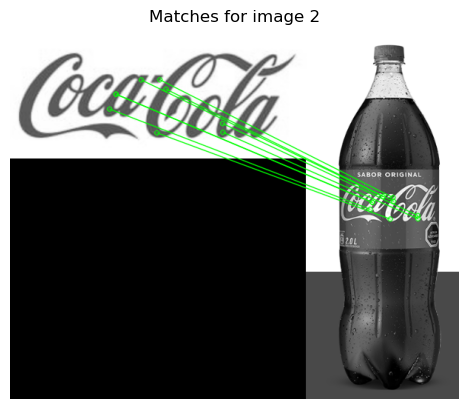

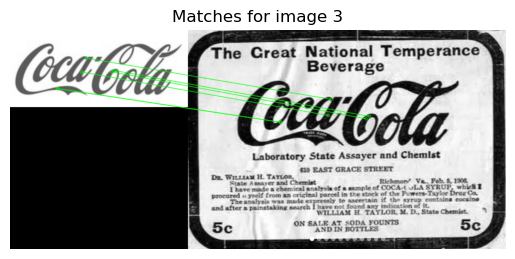

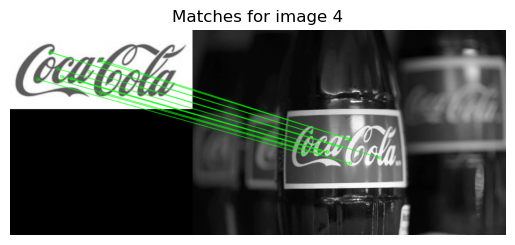

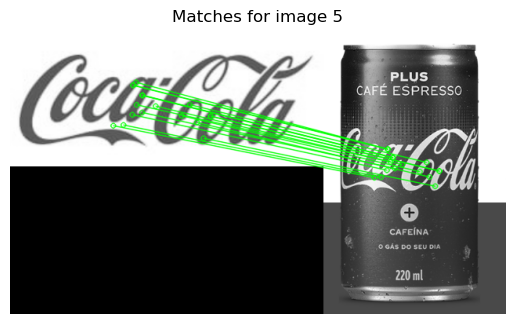

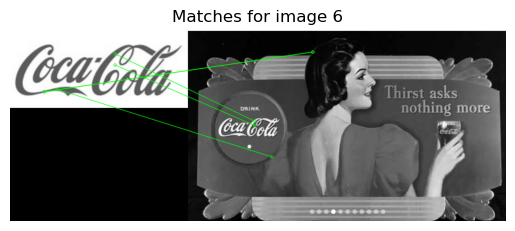

In [47]:
for i, (good, mask, img_matches) in matches.items():
    draw_params = dict(matchColor = (0,255,0), # dibujar coincidencias en verde
                       singlePointColor = None,
                       matchesMask = mask, # dibujar solo inliers
                       flags = 2)
    img_4 = cv.drawMatches(template, kp, images[i], images_kp_des[i][0], good, None, **draw_params)
    plt.imshow(img_4, 'gray')
    plt.title(f'Matches for image {i}')
    plt.axis('off')
    plt.show()